ESERCIZIO 2 DEL 20/05

Parole chiavi: simulazioni,campo,evoluzione,scala di simulazione (per la cosmologia decine di mpc, per astrofisici scale più piccole),materia oscura (la materia delle simulazioni, che ha particelle non interagenti se non per gravità-->non importa la termodinamica, a meno che non si dica chiaramente che non sia simulaz idrodinamica, come questa qua sotto potrebbe essere)
So simulare gravitazione, non so simulare bene termodinamica,barioni,oggetti specifici (in scale cosmologiche)


Si parte da condizioni iniziali: z=circa 100+powerspectrumlineare=Pl(z=100)+set di param cosmo;
poi risolvo le equa differenziali per delta della materia oscura e per la velocità u e osservo le loro soluzioni per z diverse; ogni tanto, a certi z, mi salvo gli output ottenuti, sono detti snapshot=simulazione ad un certo istante. 
Ci sono aloni di materia oscura, i semi da cui si formano le galassie; per ogni snapshot ricerco aloni, a cui associo una massa ed un raggio (ex: alone(z1),alone(z2),.....).

    NB il campo di mat fatto nella simul è discreto-->altra quantità importante=massa particella che fa DM, che ha certa risoluz: + piccola è la massa maggiore è la risoluz dell'alone di DM (ex: mpart=10^6M_solari, se ci sono barioni questa massa "scende"). M_alone=#part x mp.

Esistono anche sotto aloni, che orbitano dentro. Poi si incollano sopra a questi cataloghi di aloni e sotto aloni le galassie.
Qui utilizziamo un catalogo di aloni di DM molto massivi (da 10^14Msolari)

http://www.magneticum.org/data.html# uso Box0/mr cluster   cluster_Box0_z0.txt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq


In [ ]:
#box size in mpc/h
L=352 
volume=L**3

#create particles
x,y,z=np.genfromtxt('cluster_prof.txt',usecols=(1,2,3),unpack=True)/1000  #sono in kpc/h!!!, faccio/1000
n_points=len(x)
density=n_points/volume

In [ ]:
n_cells=64 #è un nostro parametro, def fino  ache scala voglio misuare Pk, meglio se è multiplo di 2 per dopo
cell_size=L/n_cells
print("Cell size: ",cell_size) #mpc/h

#compute the mean density
cell_mean_density=n_points/n_cells**3
print("Mean density in the cell: ",cell_mean_density) #mpc**-3/h**3

#create density grid with histogramdd
grid,edges=np.histogramdd((x,y,z),bins=(n_cells,n_cells,n_cells),range=((0,L),(0,L),(0,L)))

#compute the density field
density_field=(grid-cell_mean_density)/cell_mean_density 

Cell size:  4.015625
Mean density in the cell:  0.0006153583526611328


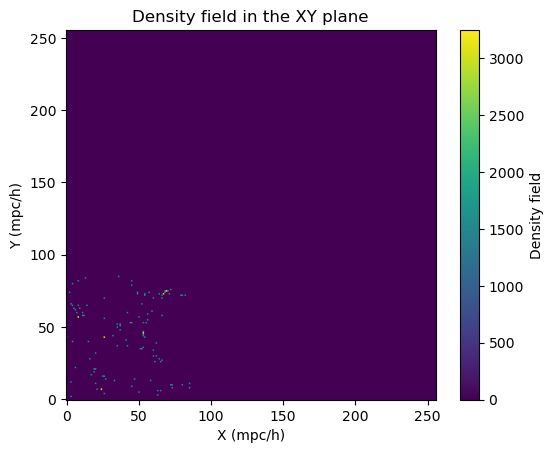

In [15]:
plt.imshow(density_field[:,:,0],origin='lower',cmap='viridis')
plt.colorbar(label='Density field')
plt.title('Density field in the XY plane')
plt.xlabel('X (mpc/h)')
plt.ylabel('Y (mpc/h)')
plt.show()

In [16]:
#compute the delta in fourier space
delta_k=rfftn(density_field)/n_cells**3  #normmalizzo per il number di celle  
#è oggetto grande: (64,64,33) e vale che f(-k)=f*(k) e f(k)=f(-k) (coniugato)

#create the k grid
kF=2*np.pi/L  #fondamental frequency in mpc**-1/h
H=L/n_cells
kN=np.pi/H   #Nyquist frequency in mpc**-1/h
kx=fftfreq(n_cells,d=1/n_cells)*kF
ky=fftfreq(n_cells,d=1/n_cells)*kF
kz=rfftfreq(n_cells,d=1/n_cells)*kF

KX,KY,KZ=np.meshgrid(kx,ky,kz)
KK=np.sqrt(KX**2+KY**2+KZ**2)  

#fftfreq(n_cells,d=1/n_cells) 

In [17]:
#calcolo spettro di pot su griglia
pk_grid=delta_k*np.conjugate(delta_k)*volume  #metto il volume perchè non sono nel continuo ma nel discreto
#ora devo fare binning griglia per avere p(|k|)
#Binning
c=1
k_edges=np.arange(kF,kN,c*kF) 
k_bins=0.5*(k_edges[1:]+k_edges[:-1])
#print("k edges: ",k_edges)

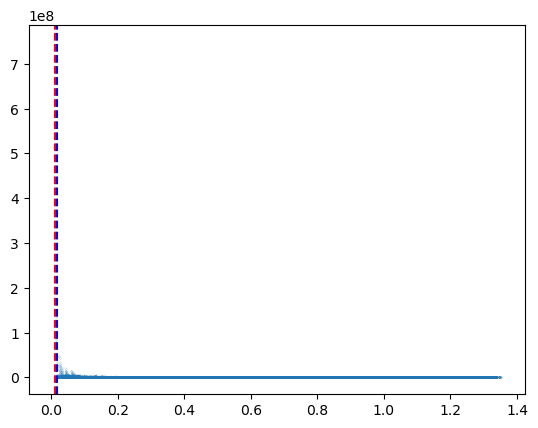

In [18]:
plt.plot(KK.flatten(),pk_grid.flatten(),'.',markersize=0.1)
plt.axvline(k_edges[1], color='red', linestyle='--', label='kF')
plt.axvline(k_edges[2], color='blue', linestyle='--', label='kN')


In [19]:
#pk_grid[0]  #sono numeri complessi, prendo il modulo

In [20]:
pk_averaged=np.zeros(k_bins.shape)
k_averaged=np.zeros(k_bins.shape)

for i in range(len(k_bins)):
    mask=(KK.flatten()>=k_edges[i]) & (KK.flatten()<k_edges[i+1])
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask])
    k_averaged[i]=np.mean(KK.flatten()[mask])
    #print("k_bins: ",k_bins[i])
    

/tmp/ipykernel_2215/2446746906.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  pk_averaged[i]=np.mean(pk_grid.flatten()[mask])


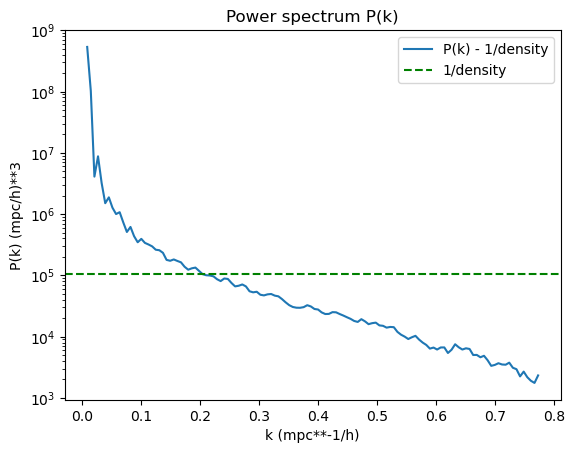

In [25]:
plt.semilogy(k_bins,pk_averaged-1./density,label='P(k) - 1/density')
plt.axhline(1./density, color='green', linestyle='--', label='1/density')
plt.xlabel('k (mpc**-1/h)')
plt.ylabel('P(k) (mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

è misura della pk della sorgente; c'è shot noise sparso e poi segnale intrinseco che è power law, le fluttuazioni che vedo sono oscillazioni, non flutt statistiche. si dovrebbe vedere anche prima del picco a sx, la salita